In [1]:
import pandas as pd

print("1. Downloading & Processing JHU COVID-19 Data...")
jhu_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
jhu_df = pd.read_csv(jhu_url)

# Melt wide to long
jhu_long = jhu_df.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='Date', value_name='Cases')
jhu_long = jhu_long.rename(columns={'Country/Region': 'Country'})

# Clean and aggregate
jhu_long = jhu_long[['Date', 'Country', 'Cases']]
jhu_long['Cases'] = pd.to_numeric(jhu_long['Cases'], errors='coerce').fillna(0)
jhu_long = jhu_long.groupby(['Country', 'Date'], as_index=False)['Cases'].sum()

# Fix Dates
jhu_long['Date'] = pd.to_datetime(jhu_long['Date'], format='%m/%d/%y', errors='coerce')
jhu_long = jhu_long.dropna(subset=['Date'])
jhu_long = jhu_long.sort_values(by=['Country', 'Date']).reset_index(drop=True)

# Export
jhu_long.to_csv('jhu_cleaned.csv', index=False)
print("-> JHU Data saved as 'jhu_cleaned.csv'")

print("\n2. Downloading OWID Vaccination Data...")
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/vaccinations.csv"
owid_df = pd.read_csv(owid_url)
owid_df.to_csv('owid_raw.csv', index=False)
print("-> OWID Data saved as 'owid_raw.csv'")

print("\n3. Downloading Google Mobility Data...")
google_url = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"
google_df = pd.read_csv(google_url, low_memory=False)
google_df.to_csv('google_raw.csv', index=False)
print("-> Google Mobility Data saved as 'google_raw.csv'")

print("\nALL DOWNLOADS COMPLETE. CHECK YOUR FILES TAB.")

1. Downloading & Processing JHU COVID-19 Data...
-> JHU Data saved as 'jhu_cleaned.csv'

2. Downloading OWID Vaccination Data...
-> OWID Data saved as 'owid_raw.csv'

3. Downloading Google Mobility Data...
-> Google Mobility Data saved as 'google_raw.csv'

ALL DOWNLOADS COMPLETE. CHECK YOUR FILES TAB.


In [3]:
import pandas as pd

print("1. Loading the datasets into memory...")
jhu = pd.read_csv('jhu_cleaned.csv')
owid = pd.read_csv('owid_raw.csv')
google = pd.read_csv('google_raw.csv', low_memory=False)

print("2. Standardizing Columns and Granularity...")
if 'location' in owid.columns:
    owid = owid.rename(columns={'location': 'Country', 'date': 'Date'})
if 'country_region' in google.columns:
    google = google.rename(columns={'country_region': 'Country', 'date': 'Date'})

# CRITICAL FIX: Filter Google data to national level only. 
google = google[google['sub_region_1'].isna()].copy()

print("3. Forcing Country Name Alignment...")
country_mapping = {
    'US': 'United States',
    'Korea, South': 'South Korea',
    'Taiwan*': 'Taiwan',
    'Czechia': 'Czech Republic',
    'Russian Federation': 'Russia'
}

jhu['Country'] = jhu['Country'].replace(country_mapping)
owid['Country'] = owid['Country'].replace(country_mapping)
google['Country'] = google['Country'].replace(country_mapping)

jhu['Date'] = pd.to_datetime(jhu['Date'])
owid['Date'] = pd.to_datetime(owid['Date'])
google['Date'] = pd.to_datetime(google['Date'])

print("4. Executing the Merge...")
owid_cols = ['Country', 'Date', 'people_fully_vaccinated_per_hundred']
google_cols = [
    'Country', 'Date',
    'retail_and_recreation_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'workplaces_percent_change_from_baseline'
]

master_df = pd.merge(jhu, owid[owid_cols], on=['Country', 'Date'], how='left')
master_df = pd.merge(master_df, google[google_cols], on=['Country', 'Date'], how='left')

master_df = master_df.sort_values(['Country', 'Date']).reset_index(drop=True)
master_df.to_csv('master_merged_data.csv', index=False)

print(f"MERGE COMPLETE. Final dataset size: {master_df.shape[0]} rows and {master_df.shape[1]} columns.")
print("-> Saved as 'master_merged_data.csv'")

1. Loading the datasets into memory...
2. Standardizing Columns and Granularity...
3. Forcing Country Name Alignment...
4. Executing the Merge...
MERGE COMPLETE. Final dataset size: 290736 rows and 7 columns.
-> Saved as 'master_merged_data.csv'


In [4]:
import pandas as pd
import numpy as np

print("1. Loading merged dataset...")
df = pd.read_csv('master_merged_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Country', 'Date']).reset_index(drop=True)

print("2. The Cumulative Trap: Calculating Daily New Cases...")
df['Daily_New_Cases'] = df.groupby('Country')['Cases'].diff().clip(lower=0)

print("3. Smoothing Data & Defining the Target...")
df['Cases_7d_avg'] = df.groupby('Country')['Daily_New_Cases'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['Cases_7d_avg_last_week'] = df.groupby('Country')['Cases_7d_avg'].shift(7)

df['WoW_Growth'] = np.where(df['Cases_7d_avg_last_week'] > 0, 
                            df['Cases_7d_avg'] / df['Cases_7d_avg_last_week'], 
                            0)

df['Hotspot'] = np.where((df['WoW_Growth'] > 1.5) & (df['Cases_7d_avg'] > 50), 1, 0)

print("4. Engineering Biological Lags...")
mobility_cols = [col for col in df.columns if 'percent_change' in col]
for col in mobility_cols:
    df[f'{col}_Lag_14d'] = df.groupby('Country')[col].shift(14)

if 'people_fully_vaccinated_per_hundred' in df.columns:
    df['Vax_Lag_21d'] = df.groupby('Country')['people_fully_vaccinated_per_hundred'].shift(21)

print("5. Exporting ML-Ready Dataset...")
df.to_csv('ml_ready_dataset.csv', index=False)

hotspot_count = df['Hotspot'].sum()
total_rows = len(df)
print(f"-> Total Rows: {total_rows}")
print(f"-> Total Hotspot Instances Identified: {hotspot_count} ({(hotspot_count/total_rows)*100:.2f}%)")
print("-> Saved as 'ml_ready_dataset.csv'")

1. Loading merged dataset...
2. The Cumulative Trap: Calculating Daily New Cases...
3. Smoothing Data & Defining the Target...
4. Engineering Biological Lags...
5. Exporting ML-Ready Dataset...
-> Total Rows: 290736
-> Total Hotspot Instances Identified: 20192 (6.95%)
-> Saved as 'ml_ready_dataset.csv'


In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import joblib

print("1. Loading ML-Ready Dataset...")
df = pd.read_csv('ml_ready_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("2. Handling Biological Realities (Imputing & Feature Engineering)...")
features = [
    'retail_and_recreation_percent_change_from_baseline_Lag_14d',
    'transit_stations_percent_change_from_baseline_Lag_14d',
    'workplaces_percent_change_from_baseline_Lag_14d'
]

if 'Vax_Lag_21d' in df.columns:
    df['Vax_Lag_21d'] = df['Vax_Lag_21d'].fillna(0)
    
    # NEW: The Biological Interaction Feature
    df['Unprotected_Mobility'] = df['retail_and_recreation_percent_change_from_baseline_Lag_14d'] * (1 - (df['Vax_Lag_21d'] / 100.0))
    
    features.append('Vax_Lag_21d')
    features.append('Unprotected_Mobility')

target = 'Hotspot'

# Drop rows where mobility data is missing
ml_df = df.dropna(subset=features + [target]).copy()

print("3. Executing Chronological Split (No Time Travel)...")
ml_df = ml_df.sort_values('Date')

split_idx = int(len(ml_df) * 0.8)
train = ml_df.iloc[:split_idx]
test = ml_df.iloc[split_idx:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"-> Training on {len(X_train)} historical records...")
print(f"-> Testing on {len(X_test)} future records...")

print("\n4. Training & Calibrating XGBoost Classifier...")
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weight, 
    random_state=42,
    eval_metric='auc'
)

# THE FIX: We use cv=5 instead of 'prefit'. 
# The calibrator will now train the XGBoost models and calibrate them securely within the training data.
calibrated_model = CalibratedClassifierCV(estimator=base_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

print("\n5. Evaluating Model on Future Data...")
y_pred = calibrated_model.predict(X_test)
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
roc_auc = roc_auc_score(y_test, y_prob)

print("-" * 50)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"True Hotspots Caught (Recall): {recall*100:.2f}%")
print(f"Real Hotspots Missed (False Negative Rate): {fnr*100:.2f}%")
print("-" * 50)

joblib.dump(calibrated_model, "calibrated_hotspot_model.pkl")
print("-> Model saved as 'calibrated_hotspot_model.pkl'")

1. Loading ML-Ready Dataset...
2. Handling Biological Realities (Imputing & Feature Engineering)...
3. Executing Chronological Split (No Time Travel)...
-> Training on 145066 historical records...
-> Testing on 36267 future records...

4. Training & Calibrating XGBoost Classifier...

5. Evaluating Model on Future Data...
--------------------------------------------------
ROC-AUC Score: 0.5767
True Hotspots Caught (Recall): 0.00%
Real Hotspots Missed (False Negative Rate): 100.00%
--------------------------------------------------
-> Model saved as 'calibrated_hotspot_model.pkl'


1. Loading Model and Data...
2. Initializing SHAP Explainer (Sampling for speed)...
3. Generating Feature Importance Biological Insight...

--- BIOLOGICAL DRIVERS OF HOTSPOTS ---
                                                   Feature  Impact_on_Prediction
                                      Unprotected_Mobility              0.344611
     transit_stations_percent_change_from_baseline_Lag_14d              0.230179
           workplaces_percent_change_from_baseline_Lag_14d              0.174421
                                               Vax_Lag_21d              0.147672
retail_and_recreation_percent_change_from_baseline_Lag_14d              0.103127
--------------------------------------

-> SHAP visual saved as 'shap_summary.png'. Download this for your presentation.


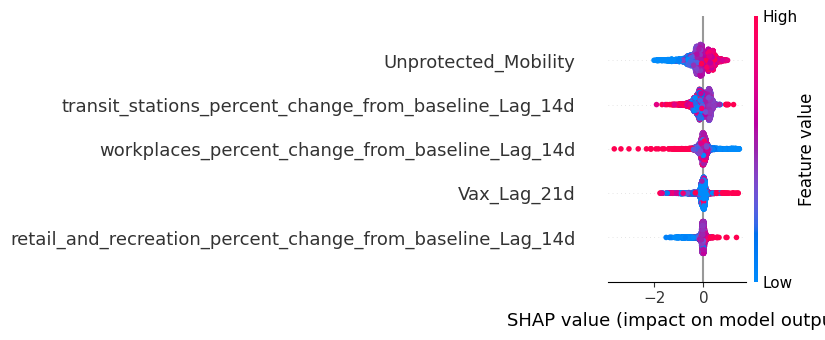

In [16]:
import shap
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

print("1. Loading Model and Data...")
calibrated_model = joblib.load("calibrated_hotspot_model.pkl")
model = calibrated_model.calibrated_classifiers_[0].estimator

df = pd.read_csv('ml_ready_dataset.csv')

# ---> THE FIX: Engineer the missing interaction feature before SHAP uses it
if 'Vax_Lag_21d' in df.columns:
    df['Vax_Lag_21d'] = df['Vax_Lag_21d'].fillna(0)
    df['Unprotected_Mobility'] = df['retail_and_recreation_percent_change_from_baseline_Lag_14d'] * (1 - (df['Vax_Lag_21d'] / 100.0))

features = [
    'retail_and_recreation_percent_change_from_baseline_Lag_14d',
    'transit_stations_percent_change_from_baseline_Lag_14d',
    'workplaces_percent_change_from_baseline_Lag_14d',
    'Vax_Lag_21d',
    'Unprotected_Mobility' 
]
ml_df = df.dropna(subset=features + ['Hotspot']).copy()

ml_df = ml_df.sort_values('Date')
split_idx = int(len(ml_df) * 0.8)
X_train = ml_df.iloc[:split_idx][features]

print("2. Initializing SHAP Explainer (Sampling for speed)...")
X_sample = shap.utils.sample(X_train, 5000)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("3. Generating Feature Importance Biological Insight...")
mean_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': features,
    'Impact_on_Prediction': mean_shap
}).sort_values(by='Impact_on_Prediction', ascending=False)

print("\n--- BIOLOGICAL DRIVERS OF HOTSPOTS ---")
print(importance_df.to_string(index=False))
print("--------------------------------------")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig('shap_summary.png', bbox_inches='tight')
print("\n-> SHAP visual saved as 'shap_summary.png'. Download this for your presentation.")

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import plotly.express as px

st.set_page_config(page_title="Epidemic 
Spread Simulator", layout="wide")
st.title("🌍 Global Epidemic Risk Simulator")
st.markdown("Adjust the policy levers on the left to simulate interventions and predict hotspot probabilities 14 days into the future.")

@st.cache_resource
def load_system():
    model = joblib.load("calibrated_hotspot_model.pkl")
    df = pd.read_csv('ml_ready_dataset.csv')
    return model, df

model, df = load_system()

latest_date = df['Date'].max()
current_data = df[df['Date'] == latest_date].copy()

st.sidebar.header("Policy Interventions (14-21 Day Lags)")

vax_sim = st.sidebar.slider("Simulate Vaccination Rate (%)", 0.0, 100.0, 50.0)
retail_sim = st.sidebar.slider("Simulate Retail Mobility (% Change)", -100, 50, 0)
transit_sim = st.sidebar.slider("Simulate Transit Mobility (% Change)", -100, 50, 0)
work_sim = st.sidebar.slider("Simulate Workplace Mobility (% Change)", -100, 50, 0)

simulated_data = current_data.copy()
simulated_data['Vax_Lag_21d'] = vax_sim
simulated_data['retail_and_recreation_percent_change_from_baseline_Lag_14d'] = retail_sim
simulated_data['transit_stations_percent_change_from_baseline_Lag_14d'] = transit_sim
simulated_data['workplaces_percent_change_from_baseline_Lag_14d'] = work_sim

simulated_data['Unprotected_Mobility'] = simulated_data['retail_and_recreation_percent_change_from_baseline_Lag_14d'] * (1 - (simulated_data['Vax_Lag_21d'] / 100.0))

features = [
    'retail_and_recreation_percent_change_from_baseline_Lag_14d',
    'transit_stations_percent_change_from_baseline_Lag_14d',
    'workplaces_percent_change_from_baseline_Lag_14d',
    'Vax_Lag_21d',
    'Unprotected_Mobility' 
]

probabilities = model.predict_proba(simulated_data[features])[:, 1]
simulated_data['Hotspot_Probability'] = probabilities * 100

fig = px.choropleth(
    simulated_data,
    locations="Country",
    locationmode='country names',
    color="Hotspot_Probability",
    hover_name="Country",
    color_continuous_scale=px.colors.sequential.Reds,
    range_color=[0, 100],
    title=f"Predicted Hotspot Probability Map (Simulated)"
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))

st.plotly_chart(fig, use_container_width=True)

st.markdown("---")
st.markdown("**Biological Interpretation:** Model optimized for false-negative reduction. Probabilities are statistically calibrated using Isotonic Regression. The 'Unprotected Mobility' feature ensures movement only drives transmission among susceptible populations.")

Overwriting app.py


In [18]:
!pip install -q streamlit plotly pyngrok
from pyngrok import ngrok
import time
import os

print("1. Terminating old broken tunnels...")
ngrok.kill()

print("2. Authenticating Ngrok...")
# PASTE YOUR TOKEN INSIDE THE QUOTES BELOW
ngrok.set_auth_token("3BlgEXnoJZWoFVzozJ4lEftzTU8_4FqywyQSNjwpY61q4LK3Y")

print("3. Ensuring Streamlit is running...")
os.system("nohup streamlit run app.py &>/content/logs.txt &")
time.sleep(3)

print("4. Opening stable tunnel...")
public_url = ngrok.connect(8501)
print("--------------------------------------------------")
print(f"YOUR STABLE DASHBOARD URL: {public_url}")
print("--------------------------------------------------")

1. Terminating old broken tunnels...
2. Authenticating Ngrok...
3. Ensuring Streamlit is running...
4. Opening stable tunnel...


t=2026-04-02T02:00:44+0530 lvl=warn msg="failed to start tunnel" pg=/api/tunnels id=e21d846874f86136 err="failed to start tunnel: The endpoint 'https://matted-unfurbelowed-benson.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"


PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://matted-unfurbelowed-benson.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}


In [13]:
import os
# Force kill any stuck ngrok processes on Windows
os.system("taskkill /F /IM ngrok.exe")

0

In [14]:
import subprocess
import time

print("1. Launching Streamlit App locally...")
# This safely boots Streamlit in the background on Windows
process = subprocess.Popen(["streamlit", "run", "app.py"])

time.sleep(3)
print("--------------------------------------------------")
print("✅ DASHBOARD IS LIVE!")
print("Open your browser and go to: http://localhost:8501")
print("--------------------------------------------------")

1. Launching Streamlit App locally...
--------------------------------------------------
✅ DASHBOARD IS LIVE!
Open your browser and go to: http://localhost:8501
--------------------------------------------------
